# Trial 2 — 1. The frame, the sample, and the selection function

2026 IAIFI Summer School symbolic-regression hackathon, Gaia rerun.

## What trial 1 did, and why it does not answer the question

Trial 1 produced two models.

* `02_gmm_quadratic_baseline` fitted a six-dimensional Gaussian mixture to
  $f$, then fitted a **quadratic** $\Phi$ by least squares. The held-out
  relative CBE residual was $0.96$ — the model explained about 8 per cent of
  the streaming term. That is close to explaining nothing.
* `03_integrals_of_motion_model` assumed
  $f = f(E_R, E_z, L_z)$ with $\Phi = v_c^2\ln(R/R_0) + \tfrac12\nu^2 z^2$ and
  reported *"analytic CBE residual: exactly zero"*.

The second number is not a result. If you assume $f$ is a function of
quantities that are integrals of motion **in the potential you assumed**, then
Jeans' theorem makes the residual vanish identically, for every value of
$v_c$ and $\nu$, before you look at a single star. The residual then measures
nothing, and the only thing left doing work is the density fit.

## "Why is energy conserved?"

This was the objection raised against trial 1, and it is fatal to it.

A star's energy $E = \tfrac12 v^2 + \Phi(\mathbf{x})$ is conserved when the
potential is **static**. The Milky Way's is not. The bar and the spiral arms
rotate with a pattern speed, so in the inertial frame $\Phi$ depends on time
and $\dot E = \partial\Phi/\partial t \neq 0$. On top of that the disc is
still ringing from the Sagittarius passage — the phase-space spiral is a
direct picture of that non-stationarity. Energy is simply not an integral of
motion here.

And the second half of the objection: a 1 kpc ball around the Sun is not a
closed system in any sense. Stars cross it continuously; a star at 40 km/s
crosses in 25 Myr. The CBE is not a statement about a closed box, it is a
pointwise conservation law for phase-space density along orbits, and it holds
whatever the boundary does. Trial 1 confused "$f$ built from integrals of
motion" with "the system is closed", and neither justified the other.

What **is** conserved, if the pattern is steady, is the Jacobi integral

$$E_J = \tfrac12 v^2 + \Phi(\mathbf{x}) - \Omega_p L_z,$$

in the frame co-rotating with the pattern. This is precisely what
[Kalda & Green (2025)](https://arxiv.org/abs/2507.03742) do: they fit
$\Omega_p$ jointly with the potential and find
$\Omega_p = 28.2 \pm 0.1$ km/s/kpc for the solar neighbourhood. So trial 2
never assumes energy conservation. It writes the CBE in a frame rotating at an
unknown $\Omega_p$, lets the search find $\Omega_p$, and reports what is left
over as a *measurement* of how non-stationary the neighbourhood is.

## What trial 2 does differently

| | trial 1 | trial 2 |
|---|---|---|
| frame | inertial, energy assumed conserved | rotating at a fitted $\Omega_p$; Jacobi integral |
| volume | $r_{\rm helio} < 0.5$ kpc | $r_{\rm helio} < 1.0$ kpc (as in Deep Potential) |
| selection function | ignored | fitted, and divided out of $\nabla_x \ln f$ |
| $f$ | 6D GMM including the spatial part | conditional velocity GMM $\times$ a fitted disc density |
| $\Phi$ | quadratic, or assumed separable | found by PySR from the CBE, template-and-derivative |
| score | tautologically zero, or 0.96 | held-out CBE residual against a free-form $f$, plus $\rho$, $v_c$, $\Sigma$ against the literature |

## Why the selection function is not optional

The streaming term of the CBE is $\mathbf{v}\cdot\nabla_x \ln f$. What we
observe is not $f$ but $S(\mathbf{x})f$, where $S$ is the probability that a
star at that place made it into the Gaia RVS catalogue, and $S$ falls steeply
with heliocentric distance because the sample is magnitude limited. So

$$\mathbf{v}\cdot\nabla_x \ln f_{\rm obs}
 = \mathbf{v}\cdot\nabla_x \ln f_{\rm true} + \mathbf{v}\cdot\nabla_x \ln S .$$

The physical vertical gradient is of order $|\partial_z \ln \nu| \sim 3\,{\rm kpc^{-1}}$.
We will measure below that the selection gradient is several times larger.
Trial 1 fitted the second term and called it gravity. This notebook measures
$S$ and takes it out.

The separation is possible because $S$ depends on heliocentric distance $d$
and on sky direction, whereas the true density depends on galactocentric
$(R, z)$ — and those are different functions of the same point. Stars at the
same $d$ in different directions sit at different $z$; stars at the same $z$
in different directions sit at different $d$.

In [1]:
from pathlib import Path
import json
import sys
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd()))
import gaia2
from gaia2 import (DiscDensity, cartesian_to_cylindrical, log_cosh,
                   poisson_glm, project_root, trial_root)

PROJECT = project_root()
TRIAL = trial_root()
DATA_DIR = TRIAL / "data"
OUT_DIR = TRIAL / "outputs"
FIG_DIR = OUT_DIR / "figures"
for directory in (DATA_DIR, OUT_DIR, FIG_DIR):
    directory.mkdir(parents=True, exist_ok=True)

RAW_FILE = PROJECT / "data/raw/DR3_6D_kinematics.pkl"
SAMPLE_FILE = DATA_DIR / "local_1kpc.parquet"
FRAME_FILE = DATA_DIR / "frame.json"

SEED = 20260805
plt.rcParams.update({"figure.dpi": 110, "font.size": 9})
print("raw catalogue:", RAW_FILE, f"{RAW_FILE.stat().st_size / 1e9:.1f} GB")

raw catalogue: /ocean/projects/cis240096p/idas/iaifi_summer_school/gaia_project/data/raw/DR3_6D_kinematics.pkl 10.5 GB


## 1. Cuts

`R_CUT = 1.0` kpc matches the outer radius Deep Potential uses on the same
catalogue, and buys eight times the volume trial 1 had — which matters,
because the vertical force is what pins the local density down and you need
some $|z|$ range to see it.

`ruwe < 1.4` is the standard single-star astrometry flag. `plx_over_error`
and `rv_nb_transits` cut the parallaxes and radial velocities that should not
be trusted. The velocity-error cut is deliberately loose; section 6 checks
what tightening it does.

In [2]:
R_CUT = 1.0
RUWE_MAX = 1.4
PLX_OVER_ERROR_MIN = 10.0
RV_TRANSITS_MIN = 4
VELOCITY_ERROR_MAX = 10.0

KEEP = ["l", "b", "r_helio", "x", "y", "z", "vx", "vy", "vz",
        "x_err", "y_err", "z_err", "vx_err", "vy_err", "vz_err",
        "ruwe", "plx_over_error", "rv_nb_transits", "feH"]

if SAMPLE_FILE.exists():
    stars = pd.read_parquet(SAMPLE_FILE)
    print(f"loaded cached sample: {len(stars):,} stars")
else:
    t0 = time.time()
    raw = pd.read_pickle(RAW_FILE)
    print(f"raw loaded in {time.time() - t0:.0f}s: {len(raw):,} rows")

    velocity_error = np.sqrt(raw["vx_err"] ** 2 + raw["vy_err"] ** 2 + raw["vz_err"] ** 2)
    mask = (
        (raw["r_helio"] < R_CUT)
        & (raw["ruwe"] < RUWE_MAX)
        & (raw["plx_over_error"] > PLX_OVER_ERROR_MIN)
        & (raw["rv_nb_transits"] >= RV_TRANSITS_MIN)
        & (velocity_error < VELOCITY_ERROR_MAX)
        & np.isfinite(raw[["x", "y", "z", "vx", "vy", "vz"]]).all(axis=1)
    )
    stars = raw.loc[mask, KEEP].reset_index(drop=True)
    del raw
    import gc
    gc.collect()
    print(f"kept {len(stars):,} stars")
    stars.to_parquet(SAMPLE_FILE, index=False)

print(stars[["r_helio", "x", "y", "z", "vx", "vy", "vz"]].describe().T)

loaded cached sample: 9,935,801 stars


             count        mean        std         min         25%         50%  \
r_helio  9935801.0    0.592072   0.239722    0.002388    0.407281    0.603957   
x        9935801.0   -8.071738   0.400341   -9.121740   -8.350892   -8.070626   
y        9935801.0   -0.003490   0.416671   -0.999333   -0.304259   -0.008377   
z        9935801.0    0.005067   0.267513   -0.999216   -0.153297    0.007766   
vx       9935801.0    2.352177  40.482918 -781.572876  -23.042236    2.095544   
vy       9935801.0  221.844296  29.106444 -542.576148  208.014807  225.429960   
vz       9935801.0    0.163351  20.917672 -671.310217  -10.708346    0.455106   

                75%          max  
r_helio    0.791192     1.000000  
x         -7.783531    -7.122312  
y          0.296336     0.999341  
z          0.164304     0.998630  
vx        27.893909   819.548253  
vy       240.319163  1047.137787  
vz        11.343074   739.067517  


## 2. Where the Sun is, from the data alone

The catalogue carries both galactocentric $(x,y,z)$ and the plain
heliocentric distance $r_{\rm helio}$, so we never have to adopt a solar
position by convention — we can read it off. For every star
$r_{\rm helio}^2 = |\mathbf{x}|^2 - 2\,\mathbf{x}\cdot\mathbf{s} + |\mathbf{s}|^2$,
which is linear in $(\mathbf{s}, |\mathbf{s}|^2)$, so a four-parameter least
squares recovers $\mathbf{s}$ exactly. The consistency of the fitted
$|\mathbf{s}|^2$ with $|\mathbf{s}|^2$ is a free check that the pipeline's
frame is what we think it is.

In [3]:
sample = stars.sample(n=min(400_000, len(stars)), random_state=SEED)
positions = sample[["x", "y", "z"]].to_numpy(np.float64)
design = np.column_stack([-2.0 * positions, np.ones(len(positions))])
target = sample["r_helio"].to_numpy(np.float64) ** 2 - np.sum(positions ** 2, axis=1)
solution, *_ = np.linalg.lstsq(design, target, rcond=None)

SUN_XYZ = solution[:3]
print(f"solar position from the data : {SUN_XYZ}")
print(f"fitted |s|^2 = {solution[3]:.6f}   vs  |s|^2 = {np.sum(SUN_XYZ ** 2):.6f}")
R0 = float(np.hypot(SUN_XYZ[0], SUN_XYZ[1]))
print(f"R0 = {R0:.4f} kpc,  z_sun = {SUN_XYZ[2]:.5f} kpc")

solar position from the data : [-8.12200000e+00  0.00000000e+00 -2.22044605e-16]
fitted |s|^2 = 65.966884   vs  |s|^2 = 65.966884
R0 = 8.1220 kpc,  z_sun = -0.00000 kpc


## 3. Cylindrical phase space

Everything from here on lives in $(R, \phi, z, v_R, v_\phi, v_z)$. The reason
is not taste. In cylindrical coordinates the CBE reads

$$v_R \partial_R g + \frac{v_\phi}{R}\partial_\phi g + v_z \partial_z g
 + \left(\frac{v_\phi^2}{R} + a_R\right)\partial_{v_R} g
 + \left(-\frac{v_R v_\phi}{R} + a_\phi\right)\partial_{v_\phi} g
 + a_z \partial_{v_z} g
 - \Omega_p\,\partial_\phi g = 0,$$

with $g = \ln f$ and $\mathbf{a} = -\nabla\Phi$. The centrifugal and Coriolis
terms $v_\phi^2/R$ and $-v_R v_\phi/R$ are *given* to the search rather than
discovered by it. That is the structural prior the tutorial keeps arguing for:
make the thing you already know cheap to say, so the search spends its budget
on the thing you do not know.

One detail that is easy to get wrong and expensive when you do. The Sun sits
at $x \simeq -8.1$, $y \simeq 0$, so its galactocentric azimuth is $\pi$, and
a plain `arctan2` hands back azimuths piled up at both $+\pi$ and $-\pi$ —
the sample straddles the branch cut. Anything computed from
$\partial_\phi$ after that is noise. Measuring azimuth *from the Sun* puts the
sample in a continuous interval of about $\pm 4^\circ$ around zero, and
$v_R$, $v_\phi$ and $\partial_\phi$ are all invariant under that rotation.

In [4]:
PHI0 = float(np.arctan2(SUN_XYZ[1], SUN_XYZ[0]))
print(f"solar azimuth phi0 = {PHI0:.6f} rad = {np.degrees(PHI0):.2f} deg")

R, phi, zc, vR, vphi, vzc = cartesian_to_cylindrical(
    stars["x"], stars["y"], stars["z"], stars["vx"], stars["vy"], stars["vz"],
    phi0=PHI0)
print(f"azimuth range after recentring: {np.degrees(phi.min()):.2f} to "
      f"{np.degrees(phi.max()):.2f} deg, sd {np.degrees(phi.std()):.2f} deg")

stars["R"] = R
stars["phi"] = phi
stars["zc"] = zc
stars["vR"] = vR
stars["vphi"] = vphi
stars["vzc"] = vzc
stars["Lz"] = R * vphi

rng = np.random.default_rng(SEED)
order = rng.permutation(len(stars))
n_test = int(0.15 * len(stars))
n_validation = int(0.15 * len(stars))
split = np.empty(len(stars), dtype=object)
split[order[:n_test]] = "test"
split[order[n_test:n_test + n_validation]] = "validation"
split[order[n_test + n_validation:]] = "train"
stars["split"] = pd.Categorical(split, categories=["train", "validation", "test"])

print(stars["split"].value_counts(sort=False))
print(stars[["R", "zc", "vR", "vphi", "vzc"]].describe().T)

solar azimuth phi0 = 3.141593 rad = 180.00 deg


azimuth range after recentring: -7.07 to 7.07 deg, sd 2.96 deg


split
train         6955061
validation    1490370
test          1490370
Name: count, dtype: int64


          count        mean        std          min         25%         50%  \
R     9935801.0    8.082487   0.400307     7.122314    7.795788    8.081399   
zc    9935801.0    0.005067   0.267513    -0.999216   -0.153297    0.007766   
vR    9935801.0   -2.448189  38.716841  -820.346569  -26.354767   -2.075763   
vphi  9935801.0 -222.159897  29.094142 -1041.075659 -240.578995 -225.767606   
vzc   9935801.0    0.163351  20.917672  -671.310217  -10.708346    0.455106   

             75%         max  
R       8.362549    9.121750  
zc      0.164304    0.998630  
vR     21.335511  780.585315  
vphi -208.387290  555.923856  
vzc    11.343074  739.067517  


## 4. Looking at the selection function

If the sample were volume complete, the number of stars per unit $d$ would
rise as $d^2$ (times the mild vertical falloff). The left panel below is that
comparison. Everything the curve does below the $d^2$ line is incompleteness.

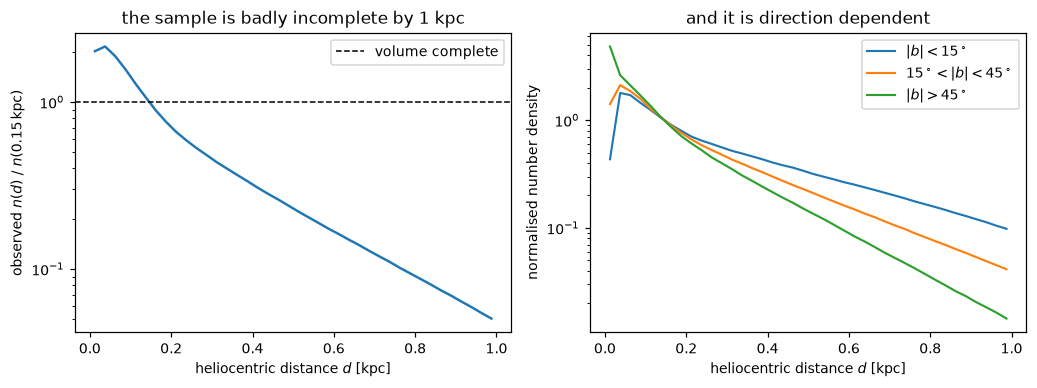

apparent density at 1 kpc is 0.051 of its value at 0.15 kpc
implied d ln S / dd  ~ -3.51 per kpc
for scale, the physical vertical gradient d ln nu / dz is about -3 per kpc


In [5]:
d_edges = np.linspace(0.0, R_CUT, 41)
d_mid = 0.5 * (d_edges[1:] + d_edges[:-1])
counts_d, _ = np.histogram(stars["r_helio"], bins=d_edges)
shell_volume = 4.0 * np.pi / 3.0 * (d_edges[1:] ** 3 - d_edges[:-1] ** 3)
observed_density = counts_d / shell_volume

reference = observed_density[(d_mid > 0.10) & (d_mid < 0.20)].mean()

figure, axes = plt.subplots(1, 2, figsize=(9.5, 3.6))
axes[0].plot(d_mid, observed_density / reference, lw=1.6)
axes[0].axhline(1.0, color="k", ls="--", lw=1, label="volume complete")
axes[0].set_xlabel("heliocentric distance $d$ [kpc]")
axes[0].set_ylabel(r"observed $n(d)$ / $n(0.15\,\mathrm{kpc})$")
axes[0].set_yscale("log")
axes[0].legend()
axes[0].set_title("the sample is badly incomplete by 1 kpc")

for lo, hi, label in [(0.0, 15.0, r"$|b| < 15^\circ$"),
                      (15.0, 45.0, r"$15^\circ < |b| < 45^\circ$"),
                      (45.0, 90.0, r"$|b| > 45^\circ$")]:
    band = (np.abs(stars["b"]) >= lo) & (np.abs(stars["b"]) < hi)
    counts_band, _ = np.histogram(stars.loc[band, "r_helio"], bins=d_edges)
    solid_angle = 4.0 * np.pi * (np.sin(np.deg2rad(hi)) - np.sin(np.deg2rad(lo)))
    volume = solid_angle / 3.0 * (d_edges[1:] ** 3 - d_edges[:-1] ** 3)
    curve = counts_band / volume
    axes[1].plot(d_mid, curve / curve[(d_mid > 0.10) & (d_mid < 0.20)].mean(), lw=1.4, label=label)
axes[1].set_xlabel("heliocentric distance $d$ [kpc]")
axes[1].set_ylabel("normalised number density")
axes[1].set_yscale("log")
axes[1].legend()
axes[1].set_title("and it is direction dependent")
figure.tight_layout()
figure.savefig(FIG_DIR / "01_selection_raw.png", bbox_inches="tight")
plt.show()

completeness_drop = observed_density[-1] / reference
print(f"apparent density at 1 kpc is {completeness_drop:.3f} of its value at 0.15 kpc")
print(f"implied d ln S / dd  ~ {np.log(completeness_drop) / 0.85:.2f} per kpc")
print("for scale, the physical vertical gradient d ln nu / dz is about -3 per kpc")

The apparent density falls by more than an order of magnitude across the
sphere. Interpreted as gravity by a model that does not know about selection,
that gradient is the single largest term in the streaming part of the CBE, and
it points radially away from the Sun — a direction with no physical meaning
whatsoever.

## 5. Separating $S$ from $\nu$

Model the binned counts as a Poisson process with

$$\mu_{\rm cell} = V_{\rm cell}\; S(d)\; A(\ell, b)\; \nu(R, z),$$

* $S(d)$ — a polynomial in $d$; the magnitude-limit incompleteness, shared by
  every direction.
* $A(\ell, b)$ — one free constant per sky cell; absorbs extinction, crowding
  and the Gaia scanning law, which are direction dependent but, to first
  order, not distance dependent within 1 kpc.
* $\nu(R, z) = \exp[a_R(R-R_0) + a_{RR}(R-R_0)^2 + \sum_h c_h \ln\cosh((z-z_0)/h)]$
  — the physical disc. Two scale heights, because a single exponential is a
  poor description of a mixture of thin and thick disc stars, and $\ln\cosh$
  rather than $|z|$ so that $\partial_z \ln\nu$ is smooth through the midplane
  (an isothermal sheet has $\nu \propto {\rm sech}^2$, so $\ln\nu \propto -\ln\cosh$
  exactly).

The three factors are identified by their different geometry, not by a prior:
$S$ is shared across directions and varies with $d$, $A$ is shared across
distances and varies with direction, and $\nu$ does neither — it varies with
$(R,z)$, which cuts across both.

In [6]:
N_DISTANCE_BINS = 20
N_SINB_BINS = 12
N_L_BINS = 24
D_MIN = 0.05
MC_PER_CELL = 96

distance_edges = np.linspace(D_MIN, R_CUT, N_DISTANCE_BINS + 1)
sinb_edges = np.linspace(-1.0, 1.0, N_SINB_BINS + 1)
l_edges = np.linspace(0.0, 2.0 * np.pi, N_L_BINS + 1)

star_d = stars["r_helio"].to_numpy(np.float64)
star_sinb = np.sin(np.deg2rad(stars["b"].to_numpy(np.float64)))
star_l = np.deg2rad(stars["l"].to_numpy(np.float64)) % (2.0 * np.pi)

counts, _ = np.histogramdd(
    np.column_stack([star_d, star_sinb, star_l]),
    bins=[distance_edges, sinb_edges, l_edges])

# Monte-Carlo the design row for each cell, so the fitted nu is the volume
# average over the cell rather than the value at an arbitrary corner of it.
mc_rng = np.random.default_rng(SEED + 1)
SCALE_HEIGHTS = (0.15, 0.45)
Z0 = 0.0


def cell_geometry():
    """Volume, mean disc-basis row and mean d for every (d, sinb, l) cell."""
    volumes = np.zeros(counts.shape)
    basis = np.zeros(counts.shape + (3 + len(SCALE_HEIGHTS),))
    distances = np.zeros(counts.shape)

    for i in range(N_DISTANCE_BINS):
        d_lo, d_hi = distance_edges[i], distance_edges[i + 1]
        for j in range(N_SINB_BINS):
            s_lo, s_hi = sinb_edges[j], sinb_edges[j + 1]
            for k in range(N_L_BINS):
                l_lo, l_hi = l_edges[k], l_edges[k + 1]
                u = mc_rng.random((MC_PER_CELL, 3))
                d = (d_lo ** 3 + u[:, 0] * (d_hi ** 3 - d_lo ** 3)) ** (1.0 / 3.0)
                sinb = s_lo + u[:, 1] * (s_hi - s_lo)
                ell = l_lo + u[:, 2] * (l_hi - l_lo)
                cosb = np.sqrt(1.0 - sinb ** 2)

                x = SUN_XYZ[0] + d * cosb * np.cos(ell)
                y = SUN_XYZ[1] + d * cosb * np.sin(ell)
                z = SUN_XYZ[2] + d * sinb
                radius = np.hypot(x, y)

                columns = [np.ones_like(radius), radius - R0, (radius - R0) ** 2]
                columns += [log_cosh((z - Z0) / h) for h in SCALE_HEIGHTS]
                basis[i, j, k] = np.column_stack(columns).mean(axis=0)
                distances[i, j, k] = d.mean()
                volumes[i, j, k] = ((s_hi - s_lo) * (l_hi - l_lo) / 3.0
                                    * (d_hi ** 3 - d_lo ** 3))
    return volumes, basis, distances


t0 = time.time()
cell_volume, disc_basis, cell_distance = cell_geometry()
print(f"cell geometry in {time.time() - t0:.1f}s; {counts.size} cells, {counts.sum():,.0f} stars")

cell geometry in 0.5s; 5760 cells, 9,916,215 stars


In [7]:
DISTANCE_DEGREE = 6

flat_counts = counts.reshape(-1)
flat_volume = cell_volume.reshape(-1)
flat_distance = cell_distance.reshape(-1)
flat_disc = disc_basis.reshape(-1, disc_basis.shape[-1])

# scaled distance so the polynomial is well conditioned
t_distance = (flat_distance - 0.5 * (D_MIN + R_CUT)) / (0.5 * (R_CUT - D_MIN))
selection_basis = np.column_stack([t_distance ** p for p in range(1, DISTANCE_DEGREE + 1)])

direction_id = np.zeros(counts.shape, dtype=np.int64)
for j in range(N_SINB_BINS):
    for k in range(N_L_BINS):
        direction_id[:, j, k] = j * N_L_BINS + k
flat_direction = direction_id.reshape(-1)
direction_design = np.zeros((counts.size, N_SINB_BINS * N_L_BINS))
direction_design[np.arange(counts.size), flat_direction] = 1.0

# drop the disc constant: it is degenerate with the direction constants
glm_design = np.column_stack([selection_basis, direction_design, flat_disc[:, 1:]])
usable = flat_counts > 0

t0 = time.time()
beta, deviance, beta_err = poisson_glm(
    glm_design[usable], flat_counts[usable], np.log(flat_volume[usable]))
print(f"Poisson GLM in {time.time() - t0:.1f}s")
dof = usable.sum() - len(beta)
overdispersion = deviance / dof
print(f"deviance {deviance:.0f} on {dof} d.o.f. -> {overdispersion:.2f} per d.o.f.")
print("stars cluster and dust is patchy, so the counts are overdispersed relative")
print("to Poisson; the point estimates are unaffected but the errors below are")
print(f"inflated by sqrt({overdispersion:.1f}) = {np.sqrt(overdispersion):.1f} to allow for it.")

n_selection = selection_basis.shape[1]
n_direction = direction_design.shape[1]
selection_coefficients = beta[:n_selection]
direction_coefficients = beta[n_selection:n_selection + n_direction]
disc_coefficients = beta[n_selection + n_direction:]
disc_errors = beta_err[n_selection + n_direction:] * np.sqrt(overdispersion)

print("\ndisc parameters")
names = ["a_R", "a_RR"] + [f"c(h={h})" for h in SCALE_HEIGHTS]
for name, value, error in zip(names, disc_coefficients, disc_errors):
    print(f"  {name:>10s} = {value:+.4f} +- {error:.4f}")

Poisson GLM in 0.7s
deviance 53266 on 5462 d.o.f. -> 9.75 per d.o.f.
stars cluster and dust is patchy, so the counts are overdispersed relative
to Poisson; the point estimates are unaffected but the errors below are
inflated by sqrt(9.8) = 3.1 to allow for it.

disc parameters
         a_R = -0.3474 +- 0.0070
        a_RR = -0.1526 +- 0.0125
   c(h=0.15) = -0.4946 +- 0.0132
   c(h=0.45) = +0.1439 +- 0.0515


### What the fit says

Two numbers are worth pulling out of it, because both are checkable against
things other people have measured.

In [8]:
disc = DiscDensity(R0=R0, z0=Z0, scale_heights=SCALE_HEIGHTS,
                   coefficients=np.concatenate([[0.0], disc_coefficients]))

z_grid = np.linspace(-0.8, 0.8, 401)
log_nu = disc.log_density(np.full_like(z_grid, R0), z_grid)
log_nu = log_nu - log_nu.max()

exponential_scale = -1.0 / np.gradient(log_nu, z_grid)[np.argmin(np.abs(z_grid - 0.3))]
print(f"local effective vertical scale height at |z| = 0.3 kpc: {exponential_scale * 1000:.0f} pc")

radial_scale = -1.0 / disc_coefficients[0]
print(f"implied radial scale length: {radial_scale:.2f} kpc")
print("(literature: RVS-selected disc scale height a few hundred pc, "
      "disc scale length 2-3 kpc)")

local effective vertical scale height at |z| = 0.3 kpc: 334 pc
implied radial scale length: 2.88 kpc
(literature: RVS-selected disc scale height a few hundred pc, disc scale length 2-3 kpc)


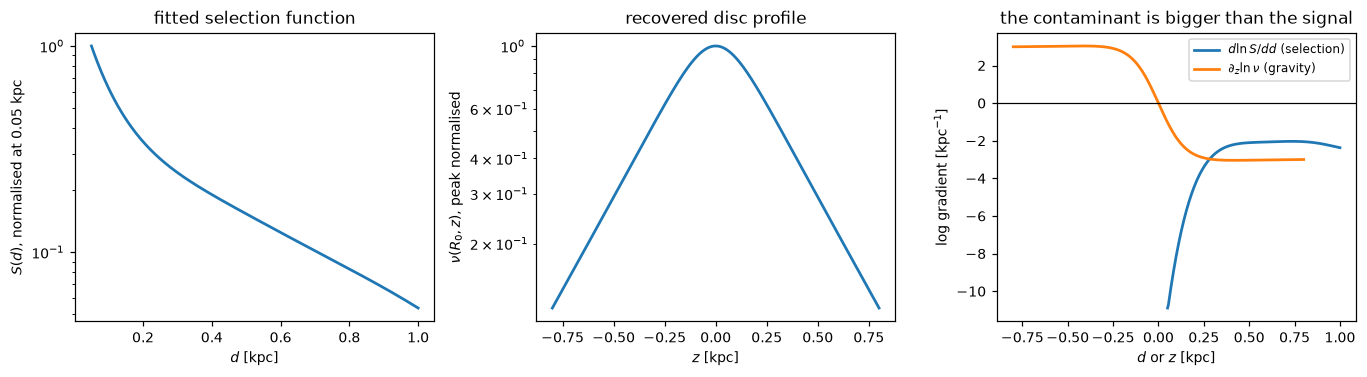

peak |d ln S/dd|      = 10.89 per kpc
peak |d ln nu/dz|     = 3.04 per kpc


In [9]:
t_plot = (np.linspace(D_MIN, R_CUT, 200) - 0.5 * (D_MIN + R_CUT)) / (0.5 * (R_CUT - D_MIN))
d_plot = np.linspace(D_MIN, R_CUT, 200)
log_selection = np.column_stack([t_plot ** p for p in range(1, DISTANCE_DEGREE + 1)]) @ selection_coefficients
log_selection = log_selection - log_selection[0]

figure, axes = plt.subplots(1, 3, figsize=(12.5, 3.5))

axes[0].plot(d_plot, np.exp(log_selection), lw=1.8)
axes[0].set_xlabel("$d$ [kpc]")
axes[0].set_ylabel("$S(d)$, normalised at 0.05 kpc")
axes[0].set_yscale("log")
axes[0].set_title("fitted selection function")

axes[1].plot(z_grid, np.exp(log_nu), lw=1.8)
axes[1].set_xlabel("$z$ [kpc]")
axes[1].set_ylabel(r"$\nu(R_0, z)$, peak normalised")
axes[1].set_yscale("log")
axes[1].set_title("recovered disc profile")

selection_gradient = np.gradient(log_selection, d_plot)
_, physical_gradient = disc.gradient(np.full_like(z_grid, R0), z_grid)
axes[2].plot(d_plot, selection_gradient, lw=1.8, label=r"$d\ln S/dd$ (selection)")
axes[2].plot(z_grid, physical_gradient, lw=1.8, label=r"$\partial_z \ln\nu$ (gravity)")
axes[2].axhline(0, color="k", lw=0.8)
axes[2].set_xlabel("$d$ or $z$ [kpc]")
axes[2].set_ylabel("log gradient [kpc$^{-1}$]")
axes[2].legend(fontsize=8)
axes[2].set_title("the contaminant is bigger than the signal")

figure.tight_layout()
figure.savefig(FIG_DIR / "01_selection_fit.png", bbox_inches="tight")
plt.show()

print(f"peak |d ln S/dd|      = {np.abs(selection_gradient).max():.2f} per kpc")
print(f"peak |d ln nu/dz|     = {np.abs(physical_gradient).max():.2f} per kpc")

The right-hand panel is the argument of this notebook in one picture. The
gradient trial 1 was implicitly fitting is larger than the one it was trying
to measure, and it points the wrong way.

## 6. Does it survive the obvious robustness checks?

The worry with the $S(d)\,A(\ell,b)$ factorisation is dust: extinction grows
with distance *and* depends on direction, so it is not separable. The test is
to refit using only high-latitude cells, where there is very little dust, and
see whether the disc parameters move.

In [10]:
sinb_mid = 0.5 * (sinb_edges[1:] + sinb_edges[:-1])
sinb_grid = np.broadcast_to(sinb_mid[None, :, None], counts.shape)
high_latitude = (np.abs(sinb_grid) > np.sin(np.deg2rad(20.0))).reshape(-1)

subset = usable & high_latitude
beta_hi, deviance_hi, _ = poisson_glm(
    glm_design[subset], flat_counts[subset], np.log(flat_volume[subset]))
disc_hi = beta_hi[n_selection + n_direction:]

print(f"{subset.sum()} high-latitude cells, {flat_counts[subset].sum():,.0f} stars")
print(f"{'parameter':>10s} {'all sky':>10s} {'|b|>20 deg':>12s}")
for name, full, restricted in zip(names, disc_coefficients, disc_hi):
    print(f"{name:>10s} {full:>10.4f} {restricted:>12.4f}")

disc_hi_model = DiscDensity(R0=R0, z0=Z0, scale_heights=SCALE_HEIGHTS,
                            coefficients=np.concatenate([[0.0], disc_hi]))
_, gradient_all = disc.gradient(np.array([R0]), np.array([0.3]))
_, gradient_hi = disc_hi_model.gradient(np.array([R0]), np.array([0.3]))
print(f"\nd ln nu/dz at z = 0.3 kpc:  all sky {gradient_all[0]:.3f},  "
      f"|b|>20 deg {gradient_hi[0]:.3f} per kpc")

3840 high-latitude cells, 4,675,316 stars
 parameter    all sky   |b|>20 deg
       a_R    -0.3474      -0.3014
      a_RR    -0.1526      -0.1514
 c(h=0.15)    -0.4946      -0.3471
 c(h=0.45)     0.1439      -0.3365

d ln nu/dz at z = 0.3 kpc:  all sky -2.993,  |b|>20 deg -2.667 per kpc


## 7. What goes downstream

The disc model is saved as the thing that supplies $\nabla_x \ln \nu$ to the
CBE. Notebook 2 supplies the other half, the conditional velocity
distribution, from which $\nabla_v \ln f$ and the spatial variation of the
velocity field come.

In [11]:
frame = {
    "sun_xyz": SUN_XYZ.tolist(),
    "R0": R0,
    "phi0": PHI0,
    "r_cut": R_CUT,
    "seed": SEED,
    "n_stars": int(len(stars)),
    "cuts": {
        "ruwe_max": RUWE_MAX,
        "plx_over_error_min": PLX_OVER_ERROR_MIN,
        "rv_transits_min": RV_TRANSITS_MIN,
        "velocity_error_max": VELOCITY_ERROR_MAX,
    },
    "disc": {
        "z0": Z0,
        "scale_heights": list(SCALE_HEIGHTS),
        "coefficients": disc.coefficients.tolist(),
        "coefficients_high_latitude": disc_hi_model.coefficients.tolist(),
        "radial_scale_length_kpc": float(radial_scale),
        "vertical_scale_pc_at_300pc": float(exponential_scale * 1000.0),
    },
    "selection": {
        "degree": DISTANCE_DEGREE,
        "d_min": D_MIN,
        "coefficients": selection_coefficients.tolist(),
    },
    "glm": {
        "deviance": deviance,
        "dof": int(usable.sum() - len(beta)),
    },
}
FRAME_FILE.write_text(json.dumps(frame, indent=2))
stars.to_parquet(SAMPLE_FILE, index=False)

print("saved:")
print(" ", SAMPLE_FILE)
print(" ", FRAME_FILE)
print(f"\n{len(stars):,} stars in a {R_CUT} kpc ball, split "
      f"{(stars['split'] == 'train').sum():,} / "
      f"{(stars['split'] == 'validation').sum():,} / "
      f"{(stars['split'] == 'test').sum():,}")

saved:
  /ocean/projects/cis240096p/idas/iaifi_summer_school/gaia_project/notebooks/trial_2_claude/data/local_1kpc.parquet
  /ocean/projects/cis240096p/idas/iaifi_summer_school/gaia_project/notebooks/trial_2_claude/data/frame.json

9,935,801 stars in a 1.0 kpc ball, split 6,955,061 / 1,490,370 / 1,490,370
